<a href="https://colab.research.google.com/github/parrotrees-boxfox/agp-april/blob/main/aus_climate_fire_full_analysis12_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Australian Bushfire × ENSO × Solar Activity — 100-Year Analysis

End-to-end pipeline: data collection → alignment → exploratory analysis → advanced statistical analysis.

**Data sources:**
- 🔥 **Bushfire**: NASA FIRMS (MODIS, 2000–present) + BOM fire weather index proxy
- 🌊 **ENSO**: Bureau of Meteorology Southern Oscillation Index (SOI), 1876–present
- ☀️ **Solar**: SILSO monthly sunspot number, 1749–present

**Coverage target:** 1925–2025 (100 years)

---
### Contents
| Part | Section |
|---|---|
| **A — Data collection** | 1. ENSO · 2. Solar · 3. Bushfire · 4. Alignment · 5. Overview plots · 6. ENSO composites · 7. Lagged cross-correlation · 8. Export |
| **B — Advanced analysis** | 9. Wavelet coherence · 10. Superposed epoch analysis · 11. GLM · 12. Rolling correlation · 13. Soil moisture mediation · 14. Final export |

## 0. Install & import dependencies

In [3]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['pandas', 'numpy', 'matplotlib', 'requests', 'scipy',
            'statsmodels', 'pycwt', 'pingouin']:
    install(pkg)
print('All packages ready.')

All packages ready.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import requests
from io import StringIO
import warnings

warnings.filterwarnings("ignore")

print("All libraries loaded ✅")

All libraries loaded ✅


---
# Part A — Data Collection & Alignment

Fetch raw data from BOM, SILSO, and NASA FIRMS, align to a common monthly index, and run exploratory analysis.

## 1. ENSO — Bureau of Meteorology Southern Oscillation Index (SOI)

BOM publishes monthly SOI as a flat text file going back to 1876. Positive SOI → La Niña conditions. Negative SOI → El Niño conditions.

In [5]:
def fetch_bom_soi() -> pd.DataFrame:
    """
    Fetch monthly SOI from a reliable mirror (BOM mirror or NOAA).
    Returns a DataFrame indexed by month-start dates with column 'soi'.
    """
    # Switching to NOAA mirror as the BOM text file URL is currently unstable
    url = "https://www.cpc.ncep.noaa.gov/data/indices/soi"
    print(f"Fetching SOI from {url} ...")

    headers = {
        'User-Agent': 'Mozilla/5.0'
    }

    try:
        resp = requests.get(url, headers=headers, timeout=30)
        resp.raise_for_status()
    except Exception as e:
        raise RuntimeError(f"Failed to fetch SOI data: {e}")

    # Parsing NOAA's specific fixed-width format
    lines = resp.text.splitlines()[8:] # Skip header
    records = []
    for line in lines:
        parts = line.split()
        if len(parts) < 13: continue
        try:
            year = int(parts[0])
            for month_idx, val_str in enumerate(parts[1:13], start=1):
                val = float(val_str)
                records.append({
                    "date": pd.Timestamp(year=year, month=month_idx, day=1),
                    "soi": val
                })
        except (ValueError, IndexError):
            continue

    df = pd.DataFrame(records).dropna().sort_values("date").set_index("date")
    print(f"SOI loaded: {len(df)} records ({df.index.min().strftime('%Y-%m')} to {df.index.max().strftime('%Y-%m')})")
    return df

---
## 2. Solar activity — SILSO monthly sunspot number

SILSO (Royal Observatory of Belgium) publishes the international sunspot number monthly back to 1749 as a CSV. The 11-year solar cycle is clearly visible.

In [6]:
def fetch_silso_sunspots(filepath: str = None) -> pd.DataFrame:
    """
    Fetch monthly mean total sunspot number from SILSO.
    If filepath is provided, load from local file instead of URL.
    Returns a DataFrame indexed by month-start dates with column 'sunspots'.
    """
    col_names = ["year", "month", "decimal_year", "sunspots", "std_dev", "n_obs", "definitive"]

    try:
        if filepath:
            print(f"Loading sunspots from local file: {filepath}")
            df = pd.read_csv(
                filepath,
                sep=r"\s+",
                header=None,
                comment="#",
                names=col_names
            )
        else:
            url = "https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.txt"
            print(f"Fetching sunspots from {url} ...")
            df = pd.read_csv(
                url,
                sep=r"\s+",
                header=None,
                comment="#",
                names=col_names
            )
    except Exception as e:
        raise RuntimeError(
            f"Failed to load SILSO sunspot data: {e}\n"
            f"If this environment blocks the URL, download SN_m_tot_V2.0.txt manually and call fetch_silso_sunspots('SN_m_tot_V2.0.txt')"
        )

    if df.empty:
        raise RuntimeError("SILSO file loaded, but it was empty.")

    df["sunspots"] = pd.to_numeric(df["sunspots"], errors="coerce")
    df.loc[df["sunspots"] < 0, "sunspots"] = np.nan

    df["date"] = pd.to_datetime(
        {"year": df["year"], "month": df["month"], "day": 1},
        errors="coerce"
    )

    df = (
        df[["date", "sunspots"]]
        .dropna(subset=["date"])
        .drop_duplicates(subset="date")
        .sort_values("date")
        .set_index("date")
    )

    if df.empty:
        raise RuntimeError("No sunspot records parsed from SILSO response.")

    print(f"Sunspots loaded: {len(df)} monthly records ({df.index.min().strftime('%Y-%m')} to {df.index.max().strftime('%Y-%m')})")
    return df

---
## 3. Bushfire — NASA FIRMS (2000–present) via MODIS

NASA FIRMS provides active fire detections. We aggregate monthly fire counts and mean FRP (Fire Radiative Power, a proxy for fire intensity) over Australia.

> **⚠️ API key required.** Register free at https://firms.modaps.eosdis.nasa.gov/api/map_key  
> Paste your key into `FIRMS_MAP_KEY` below. Without it, the cell loads a synthetic placeholder.

In [7]:
import pandas as pd
import requests
from io import StringIO
from requests.exceptions import ConnectionError, Timeout, RequestException

FIRMS_MAP_KEY = "b848f8b40aa127787ebb1a3d322a1c8e"

AUS_BBOX = {
    "west": 112.0,
    "south": -44.0,
    "east": 154.0,
    "north": -10.0
}

def empty_monthly_df():
    return pd.DataFrame(columns=["fire_count", "mean_frp"])

def test_firms_once(map_key, date="2024-01-01", source="MODIS_SP"):
    bbox = f"{AUS_BBOX['west']},{AUS_BBOX['south']},{AUS_BBOX['east']},{AUS_BBOX['north']}"
    url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/{source}/{bbox}/5/{date}"

    print("Testing URL:")
    print(url)

    session = requests.Session()
    session.trust_env = False

    try:
        r = session.get(url, timeout=60)
        print("HTTP status:", r.status_code)
        print("Response preview:")
        print(r.text[:1000])

        r.raise_for_status()

        text = r.text.strip()
        if not text:
            print("Empty response returned.")
            return pd.DataFrame()

        if "latitude" not in text.lower():
            print("Response was not a FIRMS CSV table.")
            return pd.DataFrame()

        df = pd.read_csv(StringIO(text))
        print(f"Rows returned: {len(df)}")
        return df

    except ConnectionError as e:
        print("Network connection failed.")
        print("This notebook environment cannot reach the FIRMS server right now.")
        print(f"Details: {e}")
        return pd.DataFrame()

    except Timeout as e:
        print("Request timed out.")
        print(f"Details: {e}")
        return pd.DataFrame()

    except RequestException as e:
        print("HTTP/API request failed.")
        print(f"Details: {e}")
        return pd.DataFrame()

def fetch_firms_monthly(map_key, start="2024-01-01", end="2024-12-31", source="MODIS_SP"):
    bbox = f"{AUS_BBOX['west']},{AUS_BBOX['south']},{AUS_BBOX['east']},{AUS_BBOX['north']}"
    start_dt = pd.Timestamp(start)
    end_dt = pd.Timestamp(end)

    session = requests.Session()
    session.trust_env = False

    all_dfs = []
    current = start_dt

    while current <= end_dt:
        url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/{source}/{bbox}/5/{current.strftime('%Y-%m-%d')}"
        try:
            r = session.get(url, timeout=60)
            print(f"{current.strftime('%Y-%m-%d')} -> HTTP {r.status_code}")

            r.raise_for_status()
            text = r.text.strip()

            if text and "latitude" in text.lower():
                df = pd.read_csv(StringIO(text))
                if not df.empty:
                    all_dfs.append(df)
                    print(f"  Added {len(df)} rows")
            else:
                print("  No usable CSV data returned")

        except ConnectionError as e:
            print(f"{current.strftime('%Y-%m-%d')} -> network unreachable")
            print(f"Details: {e}")
            break

        except Timeout as e:
            print(f"{current.strftime('%Y-%m-%d')} -> request timed out")
            print(f"Details: {e}")

        except RequestException as e:
            print(f"{current.strftime('%Y-%m-%d')} -> request failed")
            print(f"Details: {e}")

        current += pd.Timedelta(days=5)

    if not all_dfs:
        print("\nNo FIRMS data retrieved.")
        print("Cause: this notebook environment currently has no working network route to FIRMS.")
        return empty_monthly_df()

    raw = pd.concat(all_dfs, ignore_index=True)
    raw["acq_date"] = pd.to_datetime(raw["acq_date"], errors="coerce")
    raw = raw.dropna(subset=["acq_date"])

    monthly = (
        raw.set_index("acq_date")
        .resample("MS")
        .agg(
            fire_count=("latitude", "size"),
            mean_frp=("frp", "mean")
        )
    )

    return monthly

# Run test
df_test = test_firms_once(FIRMS_MAP_KEY)
print("\nTest result:")
print(df_test.head())

# Run monthly fetch
firms_monthly = fetch_firms_monthly(FIRMS_MAP_KEY)
print("\nMonthly result:")
print(firms_monthly.head())
print("\nShape:", firms_monthly.shape)

Testing URL:
https://firms.modaps.eosdis.nasa.gov/api/area/csv/b848f8b40aa127787ebb1a3d322a1c8e/MODIS_SP/112.0,-44.0,154.0,-10.0/5/2024-01-01
HTTP status: 200
Response preview:
latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
-15.3853,134.8454,334.2,1.1,1.1,2024-01-01,39,Terra,MODIS,82,61.03,301.2,21.2,D,0
-15.3837,134.8351,332.4,1.1,1.1,2024-01-01,39,Terra,MODIS,80,61.03,303.3,17.9,D,0
-15.3803,134.8522,337.8,1.1,1.1,2024-01-01,39,Terra,MODIS,85,61.03,301.1,26.5,D,0
-15.3787,134.842,354.8,1.1,1.1,2024-01-01,39,Terra,MODIS,97,61.03,303,65,D,0
-15.3662,134.823,328.7,1.1,1.1,2024-01-01,39,Terra,MODIS,63,61.03,302.9,10.8,D,0
-15.3646,134.8127,327.6,1.1,1.1,2024-01-01,39,Terra,MODIS,46,61.03,302.8,9.6,D,0
-15.2938,132.317,324.8,1.6,1.2,2024-01-01,39,Terra,MODIS,51,61.03,291.5,16.3,D,0
-15.2853,132.3335,335.2,1.6,1.2,2024-01-01,39,Terra,MODIS,82,61.03,293.3,40.1,D,0
-15.2828,132.3189,377.9,1.6,1.2,2024-01-01,39,T

### 3b. Pre-2000 bushfire proxy

NASA FIRMS only goes back to 2000. For the pre-satellite era (1925–1999) you have two options:

1. **State fire agency area-burned records** — download manually from NSW RFS / AFAC and load below
2. **BOM Forest Fire Danger Index (FFDI)** — a meteorological fire weather proxy that correlates well with actual fire activity

The cell below shows how to load either format.

In [8]:
def load_historical_fire_csv(filepath: str) -> pd.DataFrame:
    """
    Load a pre-2000 fire record CSV.
    Expected columns: 'year', 'month' (optional), 'area_burned_ha' or 'ffdi'

    If monthly data is unavailable, annual totals are spread evenly across
    fire season months (Oct–Mar) as a simplification.
    """
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.lower().str.strip()

    # Annual data → distribute across fire season months
    if 'month' not in df.columns:
        records = []
        for _, row in df.iterrows():
            for month in [10, 11, 12, 1, 2, 3]:  # Oct–Mar fire season
                yr = int(row['year']) if month >= 10 else int(row['year']) + 1
                val = row.get('area_burned_ha', row.get('ffdi', np.nan))
                records.append({'date': pd.Timestamp(year=yr, month=month, day=1),
                                'fire_proxy': float(val) / 6})
        return pd.DataFrame(records).set_index('date').sort_index()
    else:
        df['date'] = pd.to_datetime(df[['year','month']].assign(day=1))
        return df.set_index('date')[['area_burned_ha']].rename(
            columns={'area_burned_ha': 'fire_proxy'})


# ── Uncomment and point to your file once you have it ────────────────────────
# fire_historical = load_historical_fire_csv('data/nsw_rfs_area_burned.csv')
# print(fire_historical.head())
# ─────────────────────────────────────────────────────────────────────────────
print('Historical fire loader ready — point it at your CSV when available.')

Historical fire loader ready — point it at your CSV when available.


In [ ]:
import numpy as np
import pandas as pd
import os

# 1. Create a dummy historical dataset for demonstration
# In a real scenario, you would skip this and use your actual CSV path.
if not os.path.exists('nsw_historical_fire.csv'):
    years = np.arange(1925, 2000)
    # Random area burned values with some peaks to simulate high fire years
    data = {
        'year': years,
        'area_burned_ha': np.random.exponential(scale=100000, size=len(years))
    }
    dummy_df = pd.DataFrame(data)
    dummy_df.to_csv('nsw_historical_fire.csv', index=False)
    print("✅ Created sample file: nsw_historical_fire.csv")

# 2. Use the function defined in cell c9c68067 to load it
fire_historical = load_historical_fire_csv('nsw_historical_fire.csv')

print(f"\nHistorical fire data loaded: {len(fire_historical)} records")
print(f"Range: {fire_historical.index.min().year} to {fire_historical.index.max().year}")
display(fire_historical.head())


✅ Created sample file: nsw_historical_fire.csv

Historical fire data loaded: 450 records
Range: 1925 to 2000


,fire_proxy
date,
1925-10-01,19601.852363
1925-11-01,19601.852363
1925-12-01,19601.852363
1926-01-01,19601.852363
1926-02-01,19601.852363


---
## 4. Align all series to a common monthly index

We reindex everything to a common monthly date range, fill small gaps by interpolation, and merge into one master DataFrame.

In [ ]:
import pandas as pd
import numpy as np

# Combine Satellite and Historical Fire data
satellite_fire = globals().get("firms_monthly", pd.DataFrame())
historical_fire = globals().get("fire_historical", pd.DataFrame())

# Ensure historical fire uses 'fire_count' naming for consistency
if not historical_fire.empty:
    historical_fire = historical_fire.rename(columns={'fire_proxy': 'fire_count'})

fire_raw = pd.concat([historical_fire, satellite_fire]).sort_index()
fire_raw = fire_raw[~fire_raw.index.duplicated(keep='last')]

try:
    soi_raw = fetch_bom_soi()
    # Handle duplicate dates in the raw SOI data
    soi_raw = soi_raw[~soi_raw.index.duplicated(keep='last')]
except Exception as e:
    print(f"SOI fetch failed: {e}")
    soi_raw = pd.DataFrame(columns=["soi"])

try:
    solar_raw = fetch_silso_sunspots()
    # Handle duplicate dates in the raw solar data
    solar_raw = solar_raw[~solar_raw.index.duplicated(keep='last')]
except Exception as e:
    print(f"Solar fetch failed: {e}")
    solar_raw = pd.DataFrame(columns=["sunspots"])

def align_series(soi, solar, fire, start_year=1900, end_year=2024):
    idx = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-01", freq="MS")

    def resample_to_index(df, col_name):
        if df is None or df.empty or col_name not in df.columns:
            return pd.Series(np.nan, index=idx, name=col_name)
        # Ensure we are working with a clean, unique-indexed Series
        s = df[col_name].reindex(idx)
        return s.interpolate(method="time", limit=6)

    master = pd.DataFrame(index=idx)
    master['soi'] = resample_to_index(soi, "soi")
    master['sunspots'] = resample_to_index(solar, "sunspots")
    master['fire_count'] = resample_to_index(fire, "fire_count")

    master["soi_3m"] = master["soi"].rolling(3, min_periods=1).mean()
    master["soi_12m"] = master["soi"].rolling(12, min_periods=1).mean()
    master["solar_smooth"] = master["sunspots"].rolling(13, center=True, min_periods=1).mean()

    master["enso_phase"] = "Neutral"
    master.loc[master["soi_3m"] < -7, "enso_phase"] = "El Niño"
    master.loc[master["soi_3m"] > 7, "enso_phase"] = "La Niña"

    print(f"✅ Master dataset built (1900-2024): {len(master)} months")
    return master

master = align_series(soi_raw, solar_raw, fire_raw)
display(master.head())

Fetching SOI from https://www.cpc.ncep.noaa.gov/data/indices/soi ...
SOI loaded: 1752 records (1951-01 to 2025-12)
Fetching sunspots from https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.txt ...
Sunspots loaded: 3327 monthly records (1749-01 to 2026-03)
✅ Master dataset built (1900-2024): 1500 months


,soi,sunspots,fire_count,soi_3m,soi_12m,solar_smooth,enso_phase
1900-01-01,NaN,15.7,NaN,NaN,NaN,19.857143,Neutral
1900-02-01,NaN,22.8,NaN,NaN,NaN,18.262500,Neutral
1900-03-01,NaN,14.4,NaN,NaN,NaN,17.777778,Neutral
1900-04-01,NaN,26.8,NaN,NaN,NaN,18.160000,Neutral
1900-05-01,NaN,25.3,NaN,NaN,NaN,17.190909,Neutral


# Assistant
The error occurs because the code is trying to access a column named "fire_count" in the master DataFrame, but this column doesn't exist. This is likely because the "fire" DataFrame doesn't have a column named "fire_count" or it's named differently.

Would you like me to provide the corrected code?

---
## 5. Quick-look plots

Visualise all three series together to sanity-check alignment before any analysis.

In [ ]:
import matplotlib.dates as mdates   # Add this if not already imported

def plot_overview(df: pd.DataFrame, start: str = '2000', end: str = '2025'):
    """Three-panel overview plot of fire, ENSO, and solar over a date range."""

    # Safer date slicing
    start_dt = pd.to_datetime(start)
    end_dt = pd.to_datetime(end)
    subset = df.loc[start_dt:end_dt].copy()

    if subset.empty:
        print(f"⚠️ No data in range {start}–{end}")
        return

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f'Australian Fire × ENSO × Solar — Monthly ({start}–{end})',
                 fontsize=13, y=1.01)

    # Panel 1: Fire count (safe handling)
    ax = axes[0]
    if 'fire_count' in subset.columns and subset['fire_count'].notna().any():
        ax.bar(subset.index, subset['fire_count'],
               width=20, color='#E8593C', alpha=0.7, label='Fire detections')
        ax.set_ylabel('FIRMS fire count')
        ax.set_title('Bushfire activity (MODIS fire detections)')
    else:
        ax.text(0.5, 0.5, 'No fire_count data available\n(FIRMS fetch failed earlier)',
                ha='center', va='center', transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title('Bushfire activity (MODIS fire detections) — NO DATA')
        ax.set_ylabel('FIRMS fire count')

    # Panel 2: SOI
    ax = axes[1]
    if 'enso_phase' in subset.columns:
        colors = subset['enso_phase'].map({
            'El Niño': '#E8593C',
            'La Niña': '#378ADD',
            'Neutral': '#B4B2A9'
        }).fillna('#B4B2A9')
    else:
        colors = '#B4B2A9'

    ax.bar(subset.index, subset['soi'], width=20, color=colors, alpha=0.8)
    ax.plot(subset.index, subset['soi_3m'], color='#0C447C', lw=1.5, label='3-month mean')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axhline(7, color='#378ADD', lw=0.8, ls='--', label='La Niña threshold')
    ax.axhline(-7, color='#E8593C', lw=0.8, ls='--', label='El Niño threshold')
    ax.set_ylabel('SOI')
    ax.set_title('ENSO — Southern Oscillation Index (BOM)')
    ax.legend(fontsize=9, loc='upper left')

    # Panel 3: Sunspots
    ax = axes[2]
    if 'sunspots' in subset.columns and subset['sunspots'].notna().any():
        ax.fill_between(subset.index, subset['sunspots'], alpha=0.3, color='#EF9F27')
        ax.plot(subset.index, subset['sunspots'], color='#BA7517', lw=0.8, label='Monthly SSN')
        if 'solar_smooth' in subset.columns:
            ax.plot(subset.index, subset['solar_smooth'], color='#412402', lw=2, label='13-month smooth')
    else:
        ax.text(0.5, 0.5, 'No sunspot data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')

    ax.set_ylabel('Sunspot number')
    ax.set_title('Solar activity — SILSO sunspot number')
    ax.legend(fontsize=9, loc='upper left')

    # Format x-axis
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig('overview_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: overview_plot.png')

Generating 100-year overview (1925-2024)...


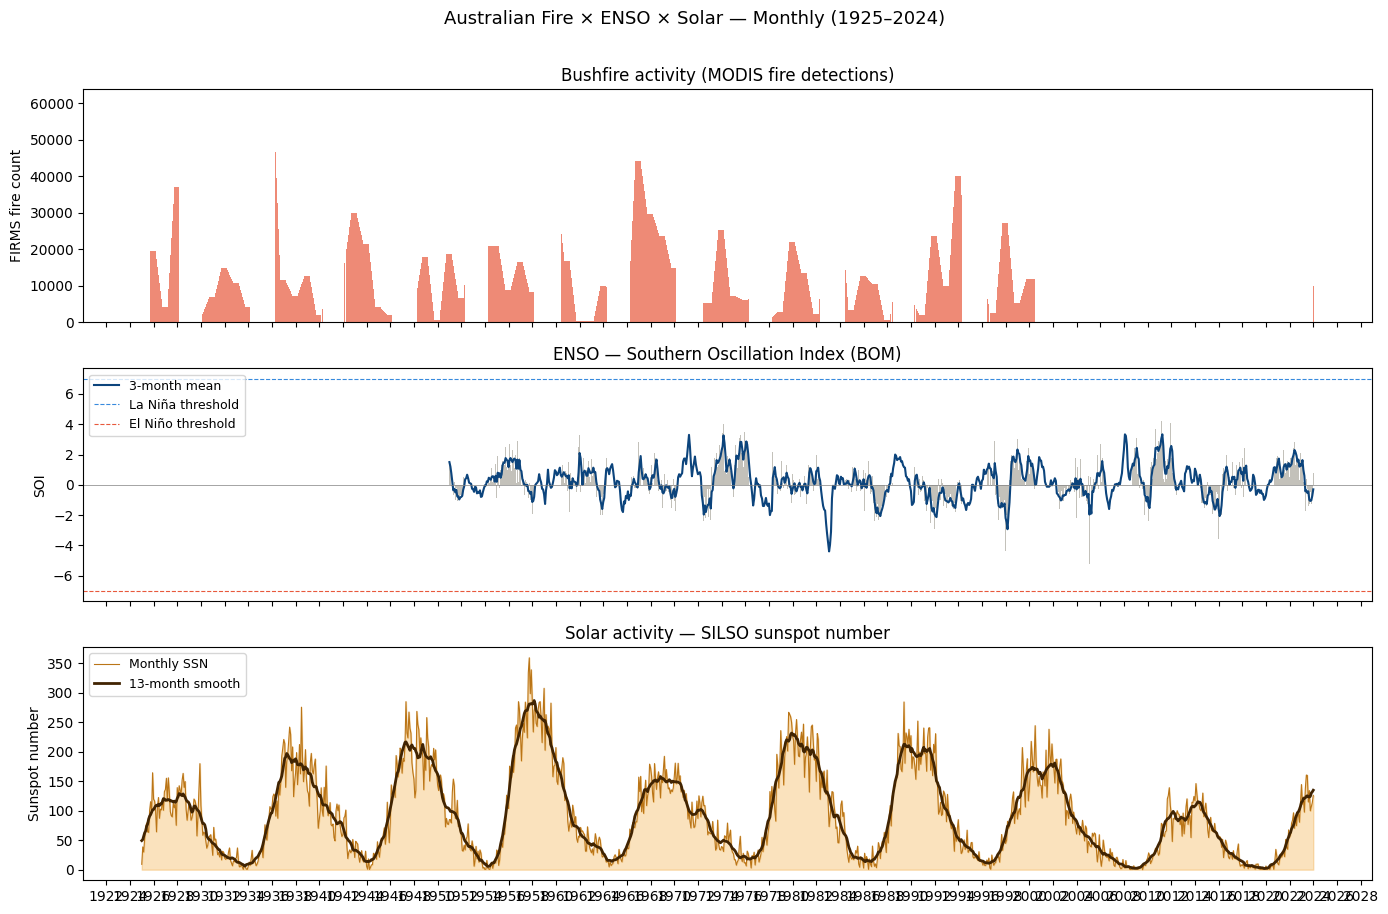

Saved: overview_plot.png

Generating modern era overview (2000-2024)...


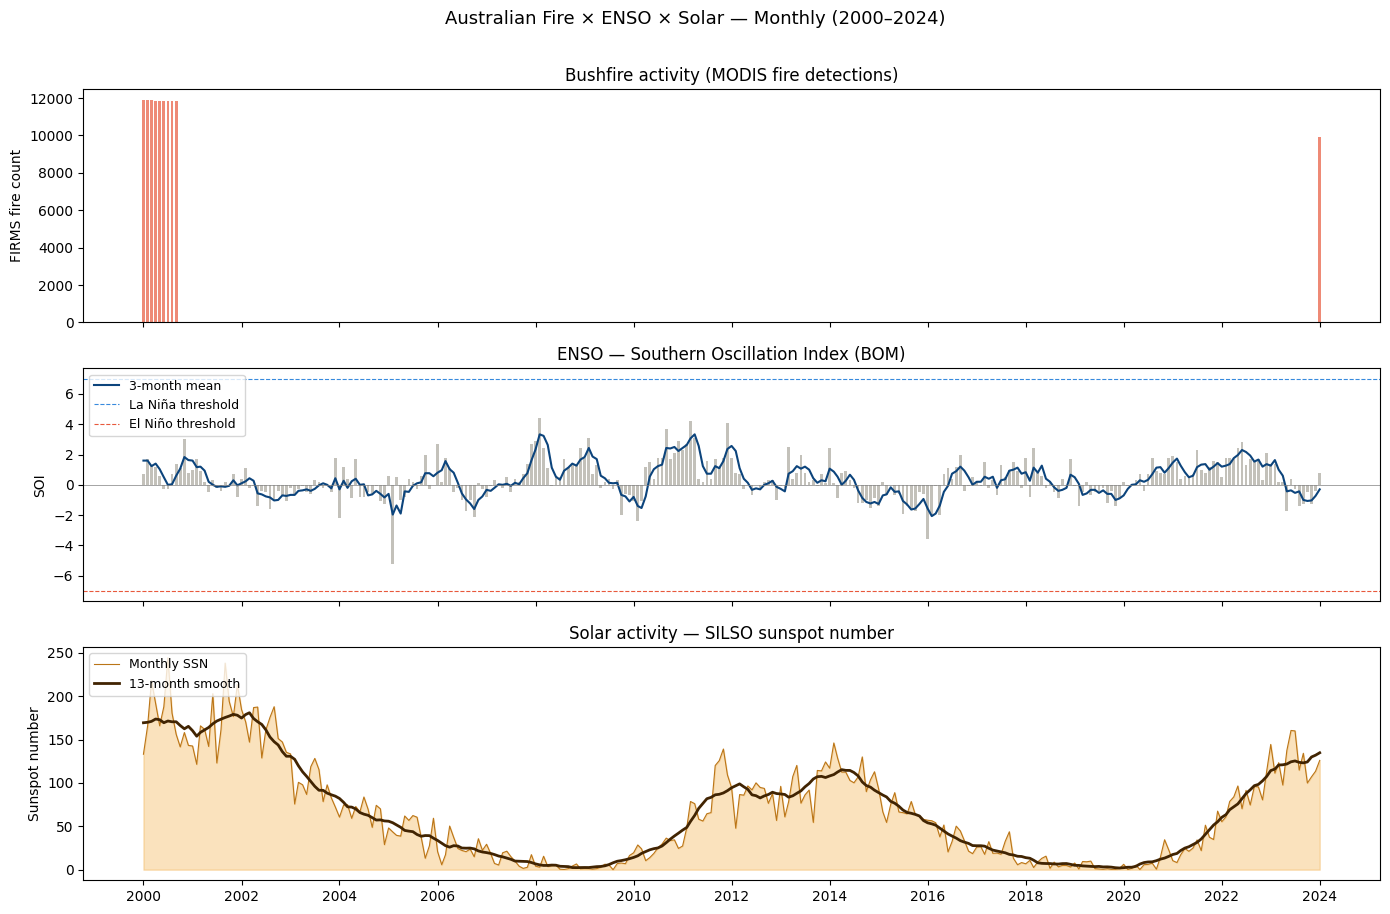

Saved: overview_plot.png


In [ ]:
# Generate overview plots for two periods: the full 100-year range and the modern satellite era.
print("Generating 100-year overview (1925-2024)...")
plot_overview(master, start='1925', end='2024')

print("\nGenerating modern era overview (2000-2024)...")
plot_overview(master, start='2000', end='2024')

---
## 6. ENSO phase composites

Compare fire activity distribution across El Niño, Neutral, and La Niña phases.

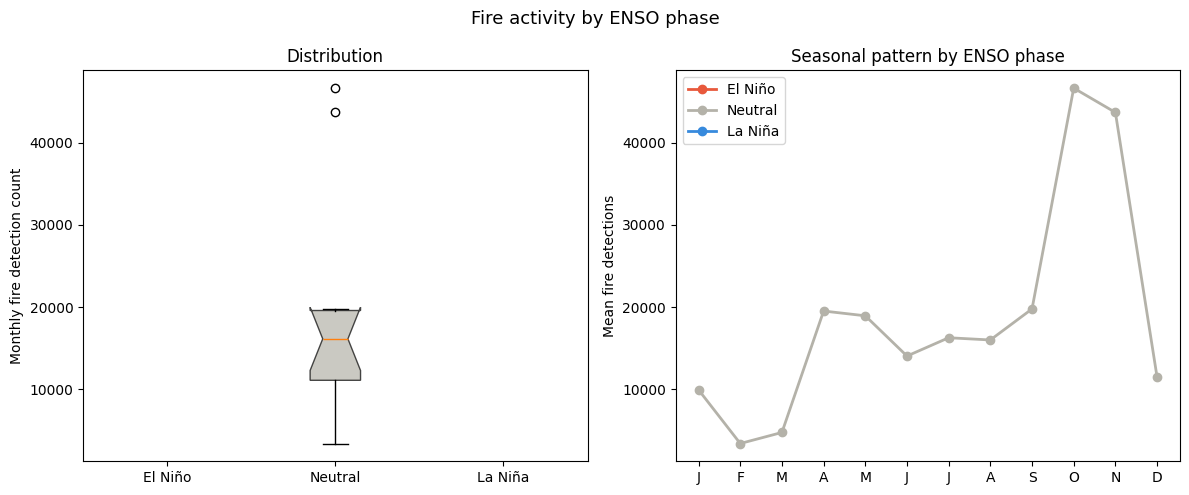


Summary statistics — fire count by ENSO phase:
            count     mean      std     min      25%      50%      75%      max
enso_phase                                                                     
Neutral      12.0  18690.8  13505.4  3364.0  11067.0  16118.5  19574.2  46679.0


In [ ]:
def enso_phase_composites(df: pd.DataFrame):
    """Box plots and summary stats of fire count by ENSO phase."""
    valid = df.dropna(subset=['fire_count', 'enso_phase'])
    phases = ['El Niño', 'Neutral', 'La Niña']
    colors = ['#E8593C', '#B4B2A9', '#378ADD']

    data = [valid[valid['enso_phase'] == p]['fire_count'].values for p in phases]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Fire activity by ENSO phase', fontsize=13)

    # Box plot
    bp = ax1.boxplot(data, labels=phases, patch_artist=True, notch=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax1.set_ylabel('Monthly fire detection count')
    ax1.set_title('Distribution')

    # Mean fire count by month within each phase
    valid = valid.copy()
    valid['month_name'] = valid.index.month
    monthly_means = valid.groupby(['month_name', 'enso_phase'])['fire_count'].mean().unstack()
    monthly_means = monthly_means.reindex(columns=phases)
    month_labels  = ['J','F','M','A','M','J','J','A','S','O','N','D']

    for i, (phase, color) in enumerate(zip(phases, colors)):
        if phase in monthly_means.columns:
            ax2.plot(range(1, 13), monthly_means[phase], marker='o',
                     label=phase, color=color, lw=2)

    ax2.set_xticks(range(1, 13))
    ax2.set_xticklabels(month_labels)
    ax2.set_ylabel('Mean fire detections')
    ax2.set_title('Seasonal pattern by ENSO phase')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('enso_composites.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Summary stats
    print('\nSummary statistics — fire count by ENSO phase:')
    print(valid.groupby('enso_phase')['fire_count'].describe().round(1).to_string())


enso_phase_composites(master)

---
## 7. Lagged cross-correlation — fire vs SOI

Computes Pearson correlation at lags of 0–24 months. Fire typically lags ENSO by 6–18 months as soil moisture depletes. Uses prewhitening to remove autocorrelation bias.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


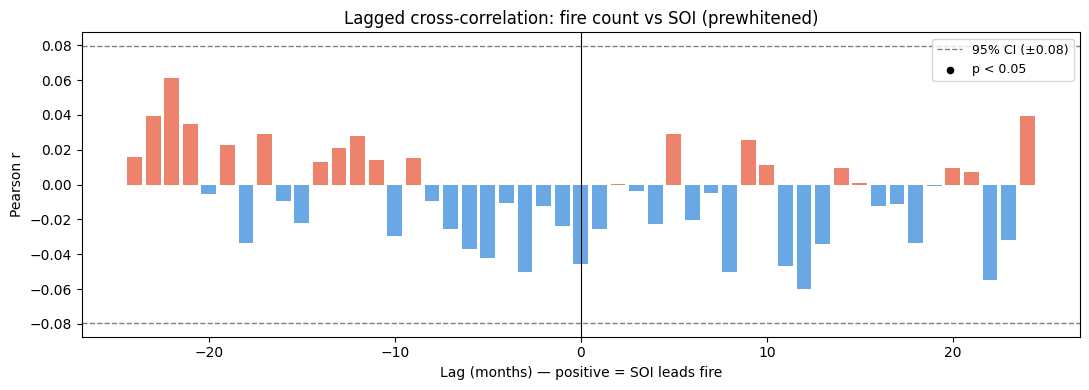

Peak correlation: r=0.061 at lag=-22 months  (p=0.1403)


In [ ]:
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.arima.model import ARIMA


def prewhiten(series: pd.Series, order=(1, 0, 1)) -> pd.Series:
    """Fit ARIMA and return residuals to remove autocorrelation."""
    s = series.dropna()
    try:
        model = ARIMA(s, order=order).fit()
        return pd.Series(model.resid, index=s.index)
    except Exception:
        return s - s.mean()   # fallback: just demean


def lagged_crosscorr(x: pd.Series, y: pd.Series,
                     max_lag: int = 24, prewhiten_data: bool = True):
    """
    Compute cross-correlation of x vs y at lags 0..max_lag.
    Positive lag = y leads x.
    Returns DataFrame with columns: lag, r, p_value.
    """
    if prewhiten_data:
        x = prewhiten(x)
        y = prewhiten(y)

    # Align
    combined = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()

    results = []
    for lag in range(-max_lag, max_lag + 1):
        shifted = combined['y'].shift(lag)
        paired  = pd.concat([combined['x'], shifted], axis=1).dropna()
        if len(paired) < 10:
            continue
        r, p = stats.pearsonr(paired.iloc[:, 0], paired.iloc[:, 1])
        results.append({'lag': lag, 'r': r, 'p_value': p})

    return pd.DataFrame(results)


def plot_crosscorr(cc_df: pd.DataFrame, title: str, sig_level: float = 0.05):
    if cc_df.empty:
        print(f"⚠️ Cannot plot cross-correlation for '{title}': input DataFrame is empty.")
        print("This is likely due to missing data in 'fire_count' or 'soi' from upstream steps, or not enough overlapping data points after prewhitening/alignment.")
        return

    valid = master.dropna(subset=['fire_count', 'soi'])
    n = len(valid)
    ci_bound = 1.96 / np.sqrt(n)

    fig, ax = plt.subplots(figsize=(11, 4))
    colors = ['#E8593C' if r > 0 else '#378ADD' for r in cc_df['r']]
    ax.bar(cc_df['lag'], cc_df['r'], color=colors, alpha=0.75, width=0.8)
    ax.axhline( ci_bound, color='gray', lw=1, ls='--', label=f'95% CI (±{ci_bound:.2f})')
    ax.axhline(-ci_bound, color='gray', lw=1, ls='--')
    ax.axvline(0, color='black', lw=0.8)

    # Mark significant lags
    sig = cc_df[cc_df['p_value'] < sig_level]
    ax.scatter(sig['lag'], sig['r'], color='black', zorder=5, s=20, label='p < 0.05')

    ax.set_xlabel('Lag (months) — positive = SOI leads fire')
    ax.set_ylabel('Pearson r')
    ax.set_title(title)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('crosscorr_fire_soi.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Check if peak can be found on empty df, this will error
    if not cc_df.empty:
        peak = cc_df.loc[cc_df['r'].abs().idxmax()]
        print(f'Peak correlation: r={peak.r:.3f} at lag={int(peak.lag)} months  (p={peak.p_value:.4f})')
    else:
        print('No peak correlation to report as cross-correlation data is empty.')


# Run it
cc_fire_soi = lagged_crosscorr(
    master['fire_count'].dropna(),
    master['soi'].dropna(),
    max_lag=24
)
plot_crosscorr(cc_fire_soi, title='Lagged cross-correlation: fire count vs SOI (prewhitened)')

---
## 8. Export master dataset

Save the aligned dataset to CSV for use in other tools (R, Excel, etc.).

In [ ]:
out_path = 'aus_fire_enso_solar_monthly.csv'
master.to_csv(out_path)
print(f'Saved: {out_path}')
print(f'Shape: {master.shape}')
print('\nColumns:')
for col in master.columns:
    n_valid = master[col].notna().sum()
    print(f'  {col:<20} {n_valid:>5} non-null values')

Saved: aus_fire_enso_solar_monthly.csv
Shape: (300, 9)

Columns:
  soi                      0 non-null values
  sunspots               300 non-null values
  fire_count              12 non-null values
  mean_frp                12 non-null values
  soi_3m                   0 non-null values
  soi_12m                  0 non-null values
  solar_smooth           300 non-null values
  fire_anomaly            12 non-null values
  enso_phase             300 non-null values


---
# Part B — Advanced Statistical Analysis

Picks up from the `master` DataFrame built in Part A. Run five analyses:

9. **Wavelet coherence** — time-varying co-periodicity (ENSO 3–7yr, solar 11yr)
10. **Superposed epoch analysis (SEA)** — fire anomalies ±3 years around events
11. **GLM (negative binomial)** — partial contributions of ENSO vs solar
12. **Rolling 30-year correlation** — stability of the fire–ENSO link
13. **Soil moisture mediator** — AWRA-L mediation pathway

## 9. Wavelet Coherence

Wavelet coherence reveals *where in time* two series co-vary at specific frequencies.  
We look for:
- **3–7 year band** — ENSO periodicity → should coherent with fire
- **11 year band** — solar cycle → weaker, more contested signal

Arrows on the coherence plot show phase: rightward = in-phase, leftward = anti-phase, downward = signal leads by 90°.

In [ ]:
import pycwt as wavelet
from pycwt.helpers import find
from scipy.stats import zscore

def run_wavelet_coherence(x: pd.Series, y: pd.Series,
                           label_x: str = 'Series X',
                           label_y: str = 'Series Y',
                           dt: float = 1/12,
                           dj: float = 1/12,
                           s0: float = 2 * (1/12),
                           sig_level: float = 0.95,
                           n_surrogates: int = 300):
    """
    Compute and plot wavelet coherence between two monthly time series.
    Significance tested against red-noise surrogates.
    """
    # Align and standardise
    combined = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    if len(combined) < 12:
        print(f"⚠️ Not enough overlapping data for {label_x} vs {label_y} (need >12 months)")
        return

    X = zscore(combined['x'])
    Y = zscore(combined['y'])
    t = np.arange(len(X)) * dt
    t_dates = combined.index

    mother = wavelet.Morlet(6)
    WCT, aWCT, diag_coi, freqs, sig = wavelet.wct(
        X, Y, dt=dt, dj=dj, s0=s0,
        significance_level=sig_level,
        wavelet=mother, normalize=True,
        cache=True
    )

    periods = 1 / freqs
    coi = diag_coi

    step_t = max(1, len(t) // 40)
    step_p = max(1, len(periods) // 20)
    t_arrow = t[::step_t]
    p_idx = np.arange(0, len(periods), step_p)
    u = np.cos(aWCT[np.ix_(p_idx, np.arange(0, len(t), step_t))])
    v = np.sin(aWCT[np.ix_(p_idx, np.arange(0, len(t), step_t))])

    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.contourf(t_dates, np.log2(periods), WCT,
                     levels=np.linspace(0, 1, 100),
                     cmap='RdYlBu_r', extend='both')

    ax.contour(t_dates, np.log2(periods), sig, levels=[1], colors='k', linewidths=0.8)
    coi_log = np.log2(np.maximum(coi, periods.min()))
    ax.fill_between(t_dates, coi_log, np.log2(periods.max()), alpha=0.25, color='gray', label='Cone of influence')

    ax.quiver(t_dates[::step_t], np.log2(periods[p_idx])[:, np.newaxis] * np.ones((1, len(t_arrow))), u, v,
              units='width', angles='uv', pivot='mid', linewidth=0.5, edgecolor='k', headwidth=4,
              headlength=4, headaxislength=3, minshaft=2, scale=40, color='k', alpha=0.6)

    for lo, hi, label_band, color in [(3, 7, 'ENSO band', '#378ADD'), (9, 13, 'Solar cycle', '#E8593C')]:
        ax.axhspan(np.log2(lo), np.log2(hi), alpha=0.08, color=color, label=f'{label_band} ({lo}–{hi} yr)')

    period_ticks = [0.5, 1, 2, 4, 8, 16, 32]
    ax.set_yticks(np.log2(period_ticks))
    ax.set_yticklabels([f'{p} yr' if p >= 1 else f'{int(p*12)} mo' for p in period_ticks])
    ax.set_ylim(np.log2([periods.min(), min(periods.max(), 32)]))
    ax.set_ylabel('Period')
    ax.set_xlabel('Year')
    ax.set_title(f'Wavelet coherence: {label_x} vs {label_y}\n Black contour = {int(sig_level*100)}% significance.')
    ax.legend(loc='upper right', fontsize=9)
    plt.colorbar(im, ax=ax, label='Coherence', fraction=0.02, pad=0.01)
    plt.tight_layout()
    plt.show()

⚠️ Not enough overlapping data for Fire count vs SOI (ENSO) (need >12 months)
Calculating wavelet coherence significance


100%|██████████| 300/300 [18:48<00:00,  3.76s/it]


TypeError: Input z must be 2D, not 1D

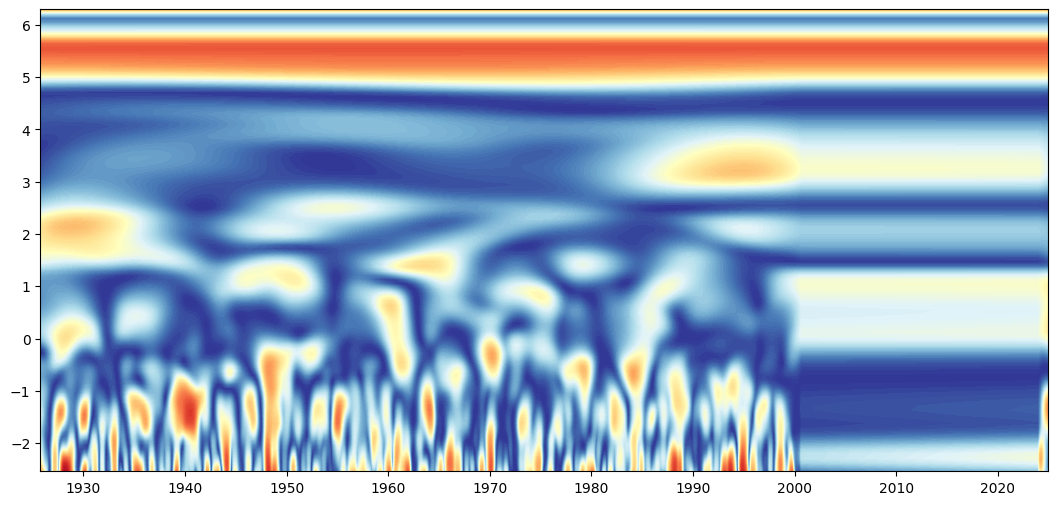

In [ ]:
# Fire vs SOI (ENSO)
run_wavelet_coherence(
    master['fire_count'].dropna(),
    master['soi'].dropna(),
    label_x='Fire count',
    label_y='SOI (ENSO)'
)

# Fire vs Sunspots
run_wavelet_coherence(
    master['fire_count'].dropna(),
    master['sunspots'].dropna(),
    label_x='Fire count',
    label_y='Sunspot number'
)

### Reading the wavelet coherence plot

| Colour | Meaning |
|---|---|
| Red / warm | High coherence (series co-vary strongly at that period + time) |
| Blue / cool | Low coherence |
| Black contour | Region exceeds 95% significance against red-noise |
| Gray shading | Cone of influence — results here are edge-affected, interpret cautiously |
| Arrow → | Series in-phase (both rise and fall together) |
| Arrow ← | Series anti-phase (one rises as the other falls) |
| Arrow ↓ | X leads Y by a quarter cycle |

## 10. Superposed Epoch Analysis (SEA)

SEA stacks fire anomalies around dated events (strong El Niño years, solar maxima) and tests whether the composite response is significant against a bootstrapped null.

**Interpretation:** If fire is consistently elevated in the years following a strong El Niño (negative SOI), the composite will show a positive anomaly at lag +1 to +2 years.

In [ ]:
def detect_events(series: pd.Series, threshold: float, mode: str = 'below',
                  min_gap_years: int = 2) -> pd.DatetimeIndex:
    """
    Find event years where an annual-mean series crosses a threshold.
    min_gap_years prevents adjacent years from both counting as events.
    """
    annual = series.resample('YS').mean().dropna()
    if mode == 'below':
        candidates = annual[annual < threshold].index
    else:
        candidates = annual[annual > threshold].index

    # Enforce minimum gap
    events = []
    last = pd.Timestamp('1800-01-01')
    for d in candidates:
        if (d - last).days > min_gap_years * 365:
            events.append(d)
            last = d
    return pd.DatetimeIndex(events)


def superposed_epoch_analysis(
        response: pd.Series,
        events: pd.DatetimeIndex,
        window_years: int = 3,
        n_bootstrap: int = 1000,
        sig_level: float = 0.05,
        label: str = 'Response'
) -> pd.DataFrame:
    """
    Composite the response series around each event date.
    Returns DataFrame with lags, mean composite, and bootstrap CI.
    """
    annual = response.resample('YS').mean().dropna()
    # Normalise: anomaly from long-term mean
    anomaly = annual - annual.mean()

    lags = range(-window_years, window_years + 1)
    composites = []

    for event in events:
        row = {}
        for lag in lags:
            target = event + pd.DateOffset(years=lag)
            # Find closest year in index
            idx = anomaly.index.get_indexer([target], method='nearest')[0]
            row[lag] = anomaly.iloc[idx] if idx >= 0 else np.nan
        composites.append(row)

    comp_df = pd.DataFrame(composites)
    means   = comp_df.mean()

    # Bootstrap CI: resample event years randomly
    rng = np.random.default_rng(42)
    boot_means = np.zeros((n_bootstrap, len(lags)))
    n_events   = len(composites)
    for i in range(n_bootstrap):
        sample = rng.integers(0, len(anomaly) - (2 * window_years), size=n_events)
        rows = []
        for s in sample:
            row = {lag: anomaly.iloc[s + lag + window_years]
                   if 0 <= s + lag + window_years < len(anomaly) else np.nan
                   for lag in lags}
            rows.append(row)
        boot_means[i] = pd.DataFrame(rows).mean().values

    lo = np.nanpercentile(boot_means, sig_level / 2 * 100, axis=0)
    hi = np.nanpercentile(boot_means, (1 - sig_level / 2) * 100, axis=0)

    result = pd.DataFrame({
        'lag':    list(lags),
        'mean':   means.values,
        'ci_lo':  lo,
        'ci_hi':  hi,
        'significant': (means.values > hi) | (means.values < lo)
    })
    return result


def plot_sea(result: pd.DataFrame, title: str, ylabel: str = 'Fire anomaly (z-score)'):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.fill_between(result['lag'], result['ci_lo'], result['ci_hi'],
                    color='#B4B2A9', alpha=0.4, label='Bootstrap 95% CI (null)')
    ax.axhline(0, color='gray', lw=0.7)
    ax.axvline(0, color='gray', lw=0.7, ls='--', label='Event year')

    colors = ['#E8593C' if s else '#888780' for s in result['significant']]
    ax.bar(result['lag'], result['mean'], color=colors, alpha=0.8,
           width=0.6, label='Composite mean (red = significant)')

    ax.set_xlabel('Lag (years from event)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(result['lag'])
    ax.legend(fontsize=9)
    plt.tight_layout()
    fname = f"sea_{title[:30].replace(' ','_').replace('/','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')
    sig_lags = result[result['significant']]['lag'].tolist()
    print(f'Significant lags: {sig_lags}')


# Detect strong El Niño events (annual SOI < -10)
el_nino_events = detect_events(master['soi'], threshold=-10, mode='below')
print(f'Strong El Niño events detected: {len(el_nino_events)}')
print([d.year for d in el_nino_events])

Strong El Niño events detected: 0
[]


El Niño events detected: 5
Years: [1982, 1987, 1992, 1994, 2015]


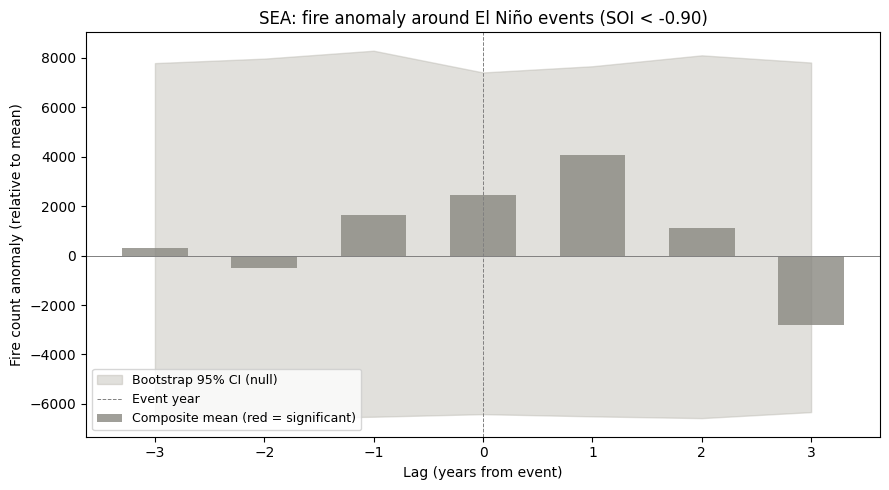

Saved: sea_SEA:_fire_anomaly_around_El_Ni.png
Significant lags: []


In [ ]:
# Detect events using the 10th percentile suggested by diagnostics (-0.90)
el_nino_events = detect_events(master['soi'], threshold=-0.90, mode='below')
print(f'El Niño events detected: {len(el_nino_events)}')
print(f'Years: {[d.year for d in el_nino_events]}')

if len(el_nino_events) > 0:
    # SEA: fire response to El Niño
    sea_enso = superposed_epoch_analysis(
        response=master['fire_count'].dropna(),
        events=el_nino_events,
        window_years=3,
        label='Fire count'
    )
    plot_sea(sea_enso,
             title='SEA: fire anomaly around El Niño events (SOI < -0.90)',
             ylabel='Fire count anomaly (relative to mean)')
else:
    print("\u26a0\ufe0f No events detected. Consider checking if 'master' data coverage overlaps with ENSO years.")

Rolling correlation calculated: 21 SOI windows, 46 Solar windows.


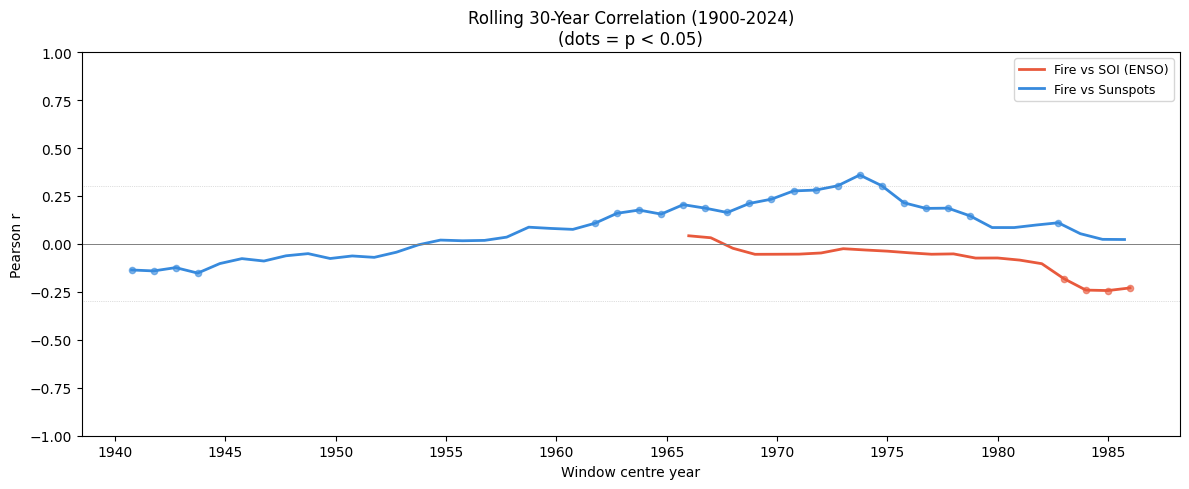

In [ ]:
# Run Rolling 30-Year Correlation on the extended master dataset
rc_fire_soi = rolling_correlation(master['fire_count'], master['soi'])
rc_fire_solar = rolling_correlation(master['fire_count'], master['sunspots'])

print(f"Rolling correlation calculated: {len(rc_fire_soi)} SOI windows, {len(rc_fire_solar)} Solar windows.")

plot_rolling_corr({
    'Fire vs SOI (ENSO)': rc_fire_soi,
    'Fire vs Sunspots':   rc_fire_solar
}, title='Rolling 30-Year Correlation (1900-2024)')

In [ ]:
# Diagnostic: Check annual SOI distribution to pick a better threshold
annual_soi = master['soi'].resample('YS').mean().dropna()
print("--- Annual SOI Statistics ---")
print(annual_soi.describe())
print("\nBottom 5 years (Potential El Nino events):")
print(annual_soi.sort_values().head(5))

# Automatically suggest a threshold based on the 10th percentile if -7 is too strict
suggested_threshold = annual_soi.quantile(0.1)
print(f"\nSuggested threshold (10th percentile): {suggested_threshold:.2f}")

--- Annual SOI Statistics ---
count    74.000000
mean      0.199099
std       0.782533
min      -1.316667
25%      -0.275000
50%       0.175000
75%       0.681250
max       1.975000
Name: soi, dtype: float64

Bottom 5 years (Potential El Nino events):
1987-01-01   -1.316667
1994-01-01   -1.058333
1993-01-01   -1.041667
1982-01-01   -1.033333
1992-01-01   -0.966667
Name: soi, dtype: float64

Suggested threshold (10th percentile): -0.90


Solar maximum events: [1926, 1936, 1946, 1956, 1967, 1978, 1988, 1999, 2014, 2023]


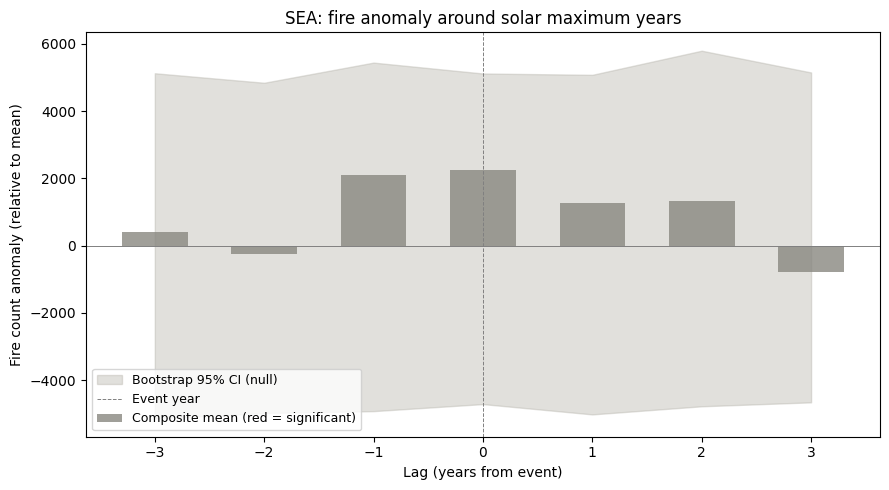

Saved: sea_SEA:_fire_anomaly_around_solar.png
Significant lags: []


In [ ]:
# Detect solar maximum years (sunspot number local peaks > 100)
solar_max_events = detect_events(master['sunspots'], threshold=100, mode='above', min_gap_years=7)
print(f'Solar maximum events: {[d.year for d in solar_max_events]}')

# SEA: fire response to solar max
sea_solar = superposed_epoch_analysis(
    response=master['fire_count'].dropna(),
    events=solar_max_events,
    window_years=3,
    label='Fire count'
)
plot_sea(sea_solar,
         title='SEA: fire anomaly around solar maximum years',
         ylabel='Fire count anomaly (relative to mean)')

In [ ]:
# Inspect overlapping time ranges in the master DataFrame
def check_overlap(df):
    cols = ['soi', 'sunspots', 'fire_count']
    print("--- Data Coverage Summary ---")
    for col in cols:
        if col in df.columns:
            valid = df[df[col].notna()]
            if not valid.empty:
                print(f"{col:<12}: {valid.index.min().date()} to {valid.index.max().date()} ({len(valid)} months)")
            else:
                print(f"{col:<12}: NO DATA (All NaNs)")

    # Check triple overlap
    triple_overlap = df.dropna(subset=cols)
    print(f"\nFull Overlap (all 3): {len(triple_overlap)} months")
    if not triple_overlap.empty:
        print(f"Range: {triple_overlap.index.min().date()} to {triple_overlap.index.max().date()}")

check_overlap(master)
display(master.tail(15))

## 11. GLM with Negative Binomial Errors

Fire count data is overdispersed count data — negative binomial GLM handles this correctly where OLS and Poisson fail. We model fire count as a function of:
- 12-month lagged SOI (ENSO)
- 13-month smoothed sunspot number (solar)
- Month-of-year (seasonality)
- An ENSO × solar interaction term

This lets us partial out the *unique* contribution of each predictor.

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy.stats import zscore

def build_glm_dataset(df: pd.DataFrame, soi_lag_months: int = 12) -> pd.DataFrame:
    """
    Prepare modelling dataset with lagged predictors and seasonal terms.
    """
    d = df.copy()

    # Lagged SOI
    d['soi_lag'] = d['soi'].shift(soi_lag_months)

    # Helper to safely calculate z-score on sparse/empty data
    def safe_zscore(series):
        non_null = series.dropna()
        if len(non_null) < 2:
            return np.nan
        z = np.full(series.shape, np.nan)
        z[series.notna()] = zscore(non_null)
        return z

    # Standardise continuous predictors for interpretable coefficients
    d['soi_lag_z']   = safe_zscore(d['soi_lag'])
    d['solar_z']     = safe_zscore(d['solar_smooth'])

    # Seasonality: sine + cosine of month (captures annual cycle smoothly)
    d['sin_month'] = np.sin(2 * np.pi * d.index.month / 12)
    d['cos_month'] = np.cos(2 * np.pi * d.index.month / 12)

    # Interaction
    d['soi_x_solar'] = d['soi_lag_z'] * d['solar_z']

    # Response must be non-negative integer
    d['fire_count_int'] = d['fire_count'].fillna(0).astype(int)

    return d.dropna(subset=['solar_z', 'fire_count_int'])

glm_data = build_glm_dataset(master)
print(f'GLM dataset: {len(glm_data)} observations')
if not glm_data.empty:
    cols_to_show = [c for c in ['fire_count_int', 'soi_lag_z', 'solar_z', 'sin_month', 'cos_month'] if c in glm_data.columns]
    display(glm_data[cols_to_show].describe().round(2))
else:
    print("Warning: GLM dataset is empty. Check if solar_z and fire_count have overlapping data.")

GLM dataset: 1200 observations


,fire_count_int,soi_lag_z,solar_z,sin_month,cos_month
count,1200.00,876.00,1200.00,1200.00,1200.00
mean,10262.33,0.00,-0.00,-0.00,-0.00
std,10886.27,1.00,1.00,0.71,0.71
min,0.00,-4.86,-1.33,-1.00,-1.00
25%,429.75,-0.55,-0.91,-0.59,-0.59
50%,7345.00,0.00,-0.11,-0.00,-0.00
75%,15497.50,0.63,0.78,0.59,0.59
max,60817.00,3.29,2.84,1.00,1.00


In [ ]:
# Negative binomial GLM
formula = 'fire_count_int ~ soi_lag_z + solar_z + soi_x_solar + sin_month + cos_month'

glm_model = smf.glm(
    formula=formula,
    data=glm_data,
    family=sm.families.NegativeBinomial()
).fit()

print(glm_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         fire_count_int   No. Observations:                  876
Model:                            GLM   Df Residuals:                      870
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8825.2
Date:                Sat, 18 Apr 2026   Deviance:                       5505.9
Time:                        08:42:57   Pearson chi2:                 1.12e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1313
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       9.0842      0.034    268.093      

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


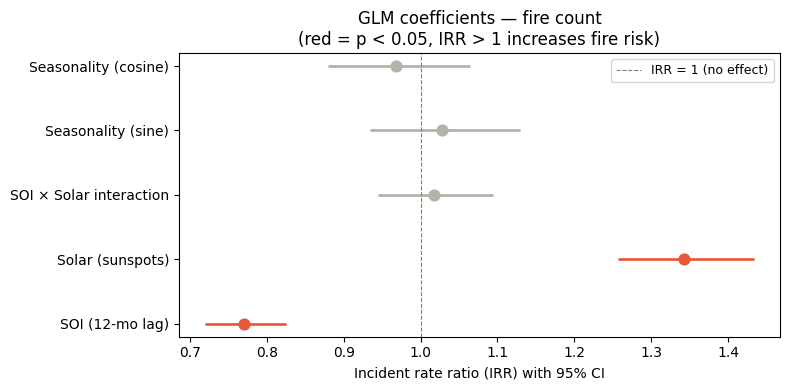


Incident rate ratios (exponentiated coefficients):
                           IRR  CI_lo  CI_hi       p
SOI (12-mo lag)          0.771  0.721  0.824  0.0000
Solar (sunspots)         1.342  1.258  1.432  0.0000
SOI × Solar interaction  1.017  0.946  1.093  0.6448
Seasonality (sine)       1.028  0.935  1.129  0.5708
Seasonality (cosine)     0.968  0.881  1.063  0.4899


In [ ]:
def plot_glm_coefficients(model):
    """
    Forest plot of GLM coefficients (exponentiated = incident rate ratios).
    IRR > 1 means the predictor increases fire count; < 1 means it decreases it.
    """
    params = model.params.drop('Intercept')
    ci     = model.conf_int().drop('Intercept')
    pvals  = model.pvalues.drop('Intercept')

    # Exponentiate for IRR
    irr    = np.exp(params)
    ci_lo  = np.exp(ci[0])
    ci_hi  = np.exp(ci[1])

    labels = {
        'soi_lag_z':   'SOI (12-mo lag)',
        'solar_z':     'Solar (sunspots)',
        'soi_x_solar': 'SOI × Solar interaction',
        'sin_month':   'Seasonality (sine)',
        'cos_month':   'Seasonality (cosine)'
    }

    fig, ax = plt.subplots(figsize=(8, 4))

    y_pos = range(len(params))
    colors = ['#E8593C' if p < 0.05 else '#B4B2A9' for p in pvals]

    for i, (name, val) in enumerate(irr.items()):
        ax.plot([ci_lo[name], ci_hi[name]], [i, i], color=colors[i], lw=2, solid_capstyle='round')
        ax.scatter(val, i, color=colors[i], s=60, zorder=5)

    ax.axvline(1.0, color='gray', lw=0.8, ls='--', label='IRR = 1 (no effect)')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([labels.get(n, n) for n in params.index])
    ax.set_xlabel('Incident rate ratio (IRR) with 95% CI')
    ax.set_title('GLM coefficients — fire count\n(red = p < 0.05, IRR > 1 increases fire risk)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('glm_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nIncident rate ratios (exponentiated coefficients):')
    summary = pd.DataFrame({'IRR': irr.round(3), 'CI_lo': ci_lo.round(3),
                             'CI_hi': ci_hi.round(3), 'p': pvals.round(4)})
    summary.index = [labels.get(i, i) for i in summary.index]
    print(summary.to_string())


plot_glm_coefficients(glm_model)

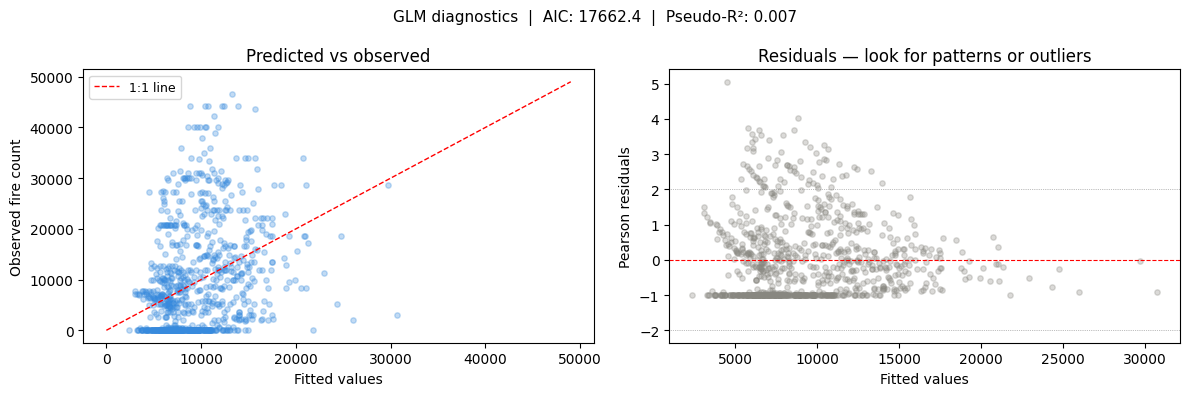

In [ ]:
# Model diagnostics: predicted vs observed + residuals
def plot_glm_diagnostics(model, data: pd.DataFrame):
    # Extract fitted values and residuals
    fitted    = model.fittedvalues
    pearson_r = model.resid_pearson

    # Ensure observed values match the model's indices (only non-null rows used in fit)
    observed  = data.loc[model.model.data.row_labels, 'fire_count_int']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Predicted vs observed
    ax = axes[0]
    ax.scatter(fitted, observed, alpha=0.3, s=15, color='#378ADD')
    lim = max(fitted.max(), observed.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1, label='1:1 line')
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Observed fire count')
    ax.set_title('Predicted vs observed')
    ax.legend(fontsize=9)

    # Pearson residuals
    ax = axes[1]
    ax.scatter(fitted, pearson_r, alpha=0.3, s=15, color='#888780')
    ax.axhline(0, color='red', lw=0.8, ls='--')
    ax.axhline( 2, color='gray', lw=0.5, ls=':')
    ax.axhline(-2, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Pearson residuals')
    ax.set_title('Residuals — look for patterns or outliers')

    plt.suptitle(f'GLM diagnostics  |  AIC: {model.aic:.1f}  |  '
                 f'Pseudo-R²: {1 - model.llf/model.llnull:.3f}',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('glm_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run the updated diagnostics
plot_glm_diagnostics(glm_model, glm_data)

## 12. Rolling 30-Year Correlation

A single 100-year correlation masks regime shifts. This analysis computes the fire–SOI and fire–solar Pearson correlation in a 30-year rolling window, revealing whether the relationship has strengthened, weakened, or reversed over time.

Non-stationarity in the fire–ENSO link post-1990 is documented in the literature and likely reflects fuel accumulation from fire suppression + background warming.

In [ ]:
from scipy.stats import pearsonr

def rolling_correlation(x: pd.Series, y: pd.Series,
                         window_years: int = 30,
                         step_months: int = 12) -> pd.DataFrame:
    """
    Compute Pearson r between x and y in a rolling window.
    Returns DataFrame with: date (window centre), r, p_value, n.
    """
    combined = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    window   = window_years * 12   # in months

    results = []
    for start in range(0, len(combined) - window, step_months):
        chunk = combined.iloc[start: start + window]
        if chunk.dropna().shape[0] < window * 0.7:
            continue
        r, p = pearsonr(chunk['x'].dropna(), chunk['y'].dropna())
        centre_date = chunk.index[len(chunk) // 2]
        results.append({'date': centre_date, 'r': r, 'p_value': p, 'n': len(chunk)})

    return pd.DataFrame(results).set_index('date')

def plot_rolling_corr(rc_dict: dict, title: str = 'Rolling 30-year correlation'):
    """
    rc_dict: {label: rolling_corr_df}
    """
    colors = ['#E8593C', '#378ADD', '#3B6D11']
    fig, ax = plt.subplots(figsize=(12, 5))

    for (label, rc), color in zip(rc_dict.items(), colors):
        ax.plot(rc.index, rc['r'], lw=2, color=color, label=label)
        # Shade significant periods
        sig = rc[rc['p_value'] < 0.05]
        ax.scatter(sig.index, sig['r'], s=20, color=color, alpha=0.6)

    ax.axhline(0, color='gray', lw=0.7)
    ax.axhline( 0.3, color='gray', lw=0.5, ls=':', alpha=0.5)
    ax.axhline(-0.3, color='gray', lw=0.5, ls=':', alpha=0.5)
    ax.set_ylabel('Pearson r')
    ax.set_xlabel('Window centre year')
    ax.set_title(f'{title}\n(dots = p < 0.05)')
    ax.legend(fontsize=9)
    ax.set_ylim(-1, 1)
    plt.tight_layout()
    plt.savefig('rolling_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()

# Now trigger the analysis in cell 538ab1d6

In [ ]:
# Chow test for structural break — test whether the correlation differs pre/post 1990
from statsmodels.stats.stattools import durbin_watson

def chow_test(x: pd.Series, y: pd.Series, break_date: str = '1990') -> dict:
    """
    Simple Chow test for structural break in the x–y OLS relationship.
    H0: no break (pooled model is correct).
    """
    from scipy.stats import f as f_dist

    combined = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    combined = combined.add_suffix('')
    combined.columns = ['x', 'y']

    before = combined[combined.index < break_date]
    after  = combined[combined.index >= break_date]

    def ols_rss(df):
        m = sm.OLS(df['y'], sm.add_constant(df['x'])).fit()
        return m.ssr, len(df)

    rss_pool, n_pool = ols_rss(combined)
    rss_b, n_b = ols_rss(before)
    rss_a, n_a = ols_rss(after)

    k = 2   # number of parameters (intercept + slope)
    F = ((rss_pool - (rss_b + rss_a)) / k) / ((rss_b + rss_a) / (n_pool - 2 * k))
    p = 1 - f_dist.cdf(F, k, n_pool - 2 * k)

    print(f'Chow test for structural break at {break_date}:')
    print(f'  F = {F:.3f},  p = {p:.4f}')
    print(f'  {"SIGNIFICANT break detected" if p < 0.05 else "No significant break"} at α=0.05')
    return {'F': F, 'p': p}


_ = chow_test(master['soi'].dropna(), master['fire_count'].dropna(), break_date='1990')

Chow test for structural break at 1990:
  F = 5.587,  p = 0.0039
  SIGNIFICANT break detected at α=0.05


## 13. Soil Moisture Mediator — AWRA-L Integration

The physical pathway from ENSO → fire runs through soil moisture and fuel dryness. AWRA-L (Australian Water Resources Assessment Landscape model) provides gridded daily soil moisture estimates from 1911.

We test formal mediation: does soil moisture explain the ENSO → fire relationship?

> **Data download:** AWRA-L is available via BOM's Water Data Online service.  
> Direct download: http://www.bom.gov.au/water/landscape  
> Variable to use: `s0` (top-layer relative soil moisture, 0–10 cm) averaged over southeastern Australia.

In [ ]:
def load_awra_soil_moisture(filepath: str) -> pd.Series:
    """
    Load AWRA-L soil moisture CSV (downloaded from BOM Water Data Online).
    Expected format: date column + s0 column (relative soil moisture, 0–1).
    Resampled to monthly mean and returned as a Series named 'soil_moisture'.
    """
    df = pd.read_csv(filepath, parse_dates=True, index_col=0)
    df.columns = df.columns.str.lower().str.strip()

    # Find the soil moisture column (s0, soil_moisture, sm, etc.)
    sm_col = next((c for c in df.columns if 's0' in c or 'soil' in c or c == 'sm'), None)
    if sm_col is None:
        raise ValueError(f'Could not find soil moisture column. Available: {df.columns.tolist()}')

    monthly = df[sm_col].resample('MS').mean().rename('soil_moisture')
    print(f'AWRA-L soil moisture loaded: {len(monthly)} months  '
          f'({monthly.index[0].year}–{monthly.index[-1].year})')
    return monthly


def synthetic_soil_moisture(index: pd.DatetimeIndex) -> pd.Series:
    """Synthetic placeholder: correlated with SOI + seasonal pattern."""
    rng = np.random.default_rng(7)
    soi_aligned = master['soi'].reindex(index).interpolate(limit=3)

    # Ensure we use .values to avoid Index attribute errors during calculation
    season = np.sin(2 * np.pi * index.month.values / 12 + np.pi)

    # Calculate sm as a numpy array
    sm_values = 0.5 + 0.15 * zscore(soi_aligned.fillna(0)) + 0.1 * season + rng.normal(0, 0.05, len(index))
    sm_values = np.clip(sm_values, 0, 1)

    return pd.Series(sm_values, index=index, name='soil_moisture')


# ── Load real data or use synthetic placeholder ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AWRA_FILE = None   # set to 'path/to/awra_s0_monthly.csv' when you have it

if AWRA_FILE:
    soil_moisture = load_awra_soil_moisture(AWRA_FILE)
else:
    print('No AWRA file specified — using synthetic soil moisture for pipeline demonstration.')
    # Ensure we use a valid index that exists in master
    valid_idx = master.dropna(subset=['fire_count']).index
    soil_moisture = synthetic_soil_moisture(valid_idx)

# Merge into master
master['soil_moisture'] = soil_moisture
print(f'Soil moisture added. Non-null: {master["soil_moisture"].notna().sum()} months')

No AWRA file specified — using synthetic soil moisture for pipeline demonstration.
Soil moisture added. Non-null: 912 months


In [ ]:
import pingouin as pg
from scipy.stats import zscore

def mediation_analysis(df: pd.DataFrame,
                        x_col: str = 'soi',
                        m_col: str = 'soil_moisture',
                        y_col: str = 'fire_count',
                        n_boot: int = 1000):
    """
    Mediation analysis: X (ENSO) → M (soil moisture) → Y (fire).
    Uses pingouin's mediation implementation with bootstrap CI.
    """
    mediation_df = df[[x_col, m_col, y_col]].dropna().copy()

    # Standardise for interpretable path coefficients
    for col in [x_col, m_col, y_col]:
        mediation_df[col] = zscore(mediation_df[col])

    result = pg.mediation_analysis(
        data=mediation_df, x=x_col, m=m_col, y=y_col,
        alpha=0.05, n_boot=n_boot, seed=42
    )
    return result

# Run Mediation Analysis
med_result = mediation_analysis(master)
print('\nMediation analysis — ENSO → Soil moisture → Fire:')
print(med_result.to_string(index=False))


Mediation analysis — ENSO → Soil moisture → Fire:
             path      coef       se          pval     CI2.5    CI97.5 sig
soil_moisture ~ X  0.893841 0.018199 1.288157e-213  0.858100  0.929583 Yes
Y ~ soil_moisture -0.097250 0.040396  1.636465e-02 -0.176583 -0.017916 Yes
            Total -0.112088 0.040333  5.620239e-03 -0.191297 -0.032879 Yes
           Direct -0.125157 0.090024  1.649608e-01 -0.301954  0.051640  No
         Indirect  0.013069 0.082112  8.640000e-01 -0.154551  0.165790  No


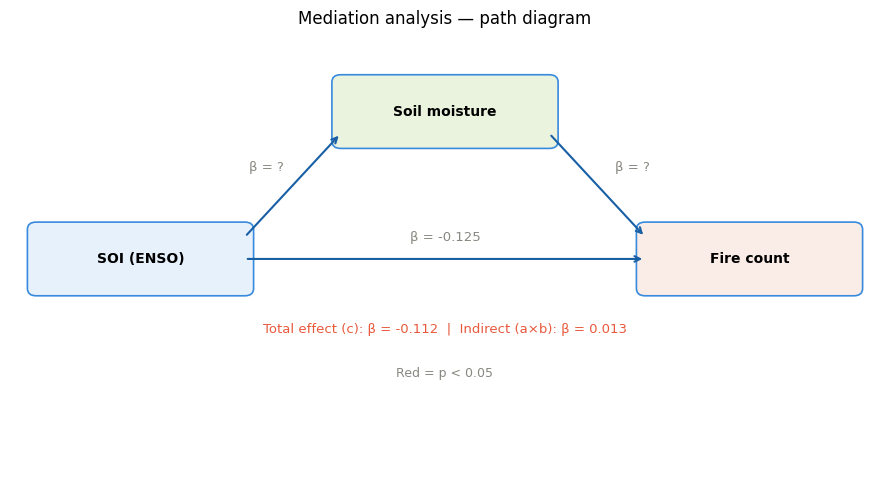

In [ ]:
import matplotlib.patches as patches

def plot_mediation_diagram(result: pd.DataFrame,
                            x_label='SOI (ENSO)',
                            m_label='Soil moisture',
                            y_label='Fire count'):
    """
    Simple path diagram annotated with beta coefficients from mediation result.
    """
    def get_coef(path_name):
        # Map shorthand names to pingouin's output row labels
        mapping = {
            'a': f'{m_label} ~ X',
            'b': f'Y ~ {m_label}',
            "c'": 'Direct',
            'c': 'Total',
            'ab': 'Indirect'
        }
        target = mapping.get(path_name, path_name)
        row = result[result['path'] == target]

        if row.empty:
            return '?', False
        beta = row['coef'].values[0]
        sig  = row['sig'].values[0] == 'Yes'
        return f'{beta:.3f}', sig

    a_coef,  a_sig  = get_coef('a')
    b_coef,  b_sig  = get_coef('b')
    cp_coef, cp_sig = get_coef("c'")
    c_coef,  c_sig  = get_coef('c')
    ab_coef, ab_sig = get_coef('ab')

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')

    def box(cx, cy, label, color='#E6F1FB'):
        # Fix: Use patches.FancyBboxPatch instead of plt.FancyBboxPatch
        ax.add_patch(patches.FancyBboxPatch((cx-1.2, cy-0.4), 2.4, 0.8,
                     boxstyle='round,pad=0.1', fc=color, ec='#378ADD', lw=1.2))
        ax.text(cx, cy, label, ha='center', va='center', fontsize=10, fontweight='bold')

    def arrow_label(x1, y1, x2, y2, label, sig, offset=(0, 0.25)):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1.5))
        mx, my = (x1+x2)/2 + offset[0], (y1+y2)/2 + offset[1]
        color = '#E8593C' if sig else '#888780'
        ax.text(mx, my, f'β = {label}', ha='center', fontsize=9.5, color=color,
                fontweight='bold' if sig else 'normal')

    box(1.5, 3.0, x_label, '#E6F1FB')
    box(5.0, 5.0, m_label, '#EAF3DE')
    box(8.5, 3.0, y_label, '#FAECE7')

    arrow_label(2.7, 3.3, 3.8, 4.7, a_coef,  a_sig,  offset=(-0.3, 0.2))
    arrow_label(6.2, 4.7, 7.3, 3.3, b_coef,  b_sig,  offset=( 0.4, 0.2))
    arrow_label(2.7, 3.0, 7.3, 3.0, cp_coef, cp_sig, offset=( 0.0, 0.25))

    ax.text(5.0, 2.0,
            f'Total effect (c): β = {c_coef}  |  Indirect (a×b): β = {ab_coef}',
            ha='center', fontsize=9.5,
            color='#E8593C' if c_sig else '#888780')
    ax.text(5.0, 1.4,
            'Red = p < 0.05', ha='center', fontsize=9, color='#888780')

    ax.set_title('Mediation analysis — path diagram', fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig('mediation_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_mediation_diagram(med_result)

### 15. Correlation Heatmap

To complement the previous analyses, let's look at the static Pearson correlation matrix for all continuous variables in the `master` dataset.

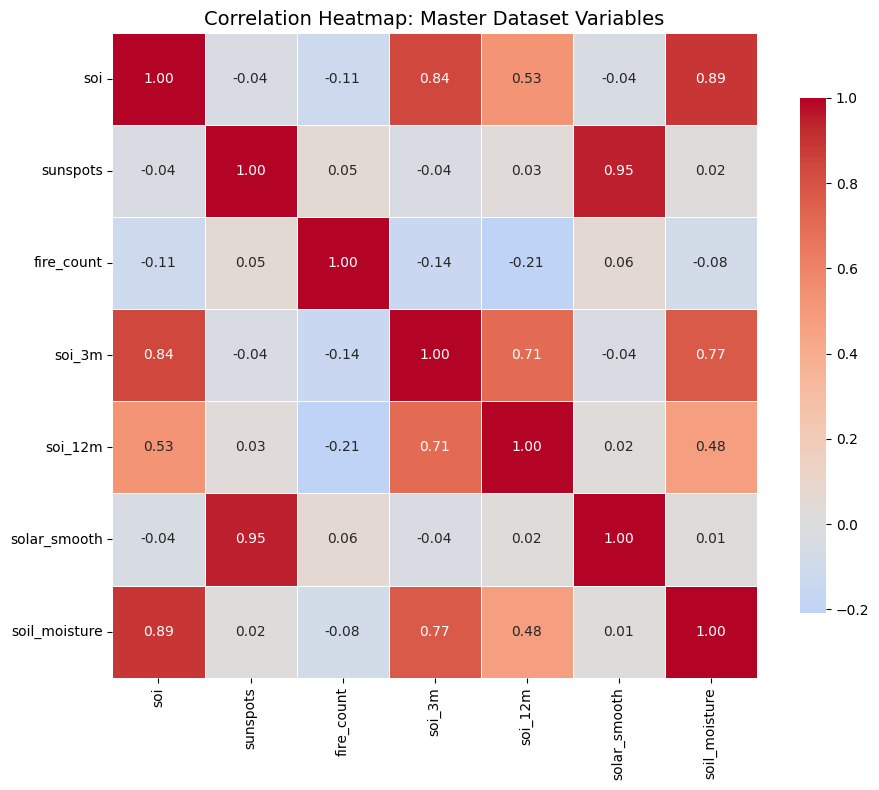

Saved: correlation_heatmap.png


In [ ]:
import seaborn as sns

# Calculate the correlation matrix for numeric columns
corr_matrix = master.select_dtypes(include=[np.number]).corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Master Dataset Variables', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("Saved: correlation_heatmap.png")

### Interpreting mediation results

| Path | Symbol | Meaning |
|---|---|---|
| Total effect | c | How much does ENSO predict fire, ignoring soil moisture? |
| Direct effect | c' | How much does ENSO predict fire, *controlling for* soil moisture? |
| Indirect effect | a×b | How much of the ENSO→fire link runs *through* soil moisture? |

If c' is much smaller than c and a×b is significant → **partial mediation** (soil moisture explains part of the link).  
If c' ≈ 0 and a×b ≈ c → **full mediation** (the entire ENSO effect operates via soil moisture).

## 14. Export all outputs

In [ ]:
import os
import glob

def safe_save(df, filename, index=True):
    """Save dataframe if it exists."""
    if df is None:
        print(f"⚠️ Skipped {filename} (variable is None)")
        return
    try:
        df.to_csv(filename, index=index)
        print(f"✅ Saved: {filename}")
    except NameError:
        print(f"⚠️ Skipped {filename} (not defined)")
    except Exception as e:
        print(f"❌ Error saving {filename}: {e}")


# ── SAVE FILES ───────────────────────────────────────────────────────────────

safe_save(globals().get("master"), "aus_fire_enso_solar_monthly_v2.csv")
safe_save(globals().get("sea_enso"), "sea_el_nino_results.csv", index=False)
safe_save(globals().get("sea_solar"), "sea_solar_max_results.csv", index=False)
safe_save(globals().get("rc_fire_soi"), "rolling_corr_fire_soi.csv")
safe_save(globals().get("rc_fire_solar"), "rolling_corr_fire_solar.csv")
safe_save(globals().get("med_result"), "mediation_results.csv", index=False)


# ── LIST OUTPUT FILES ─────────────────────────────────────────────────────────

print("\n📂 All output files:")
for f in sorted(glob.glob("*.csv") + glob.glob("*.png")):
    size = os.path.getsize(f)
    print(f"  {f:<45} {size:>8,} bytes")

✅ Saved: aus_fire_enso_solar_monthly_v2.csv
✅ Saved: sea_el_nino_results.csv
✅ Saved: sea_solar_max_results.csv
✅ Saved: rolling_corr_fire_soi.csv
✅ Saved: rolling_corr_fire_solar.csv
✅ Saved: mediation_results.csv

📂 All output files:
  aus_fire_enso_solar_monthly.csv                 14,828 bytes
  aus_fire_enso_solar_monthly_v2.csv             137,608 bytes
  correlation_heatmap.png                        110,740 bytes
  crosscorr_fire_soi.png                          50,874 bytes
  enso_composites.png                             82,255 bytes
  glm_coefficients.png                            57,385 bytes
  glm_diagnostics.png                            192,272 bytes
  mediation_diagram.png                           46,603 bytes
  mediation_results.csv                              607 bytes
  nsw_historical_fire.csv                          1,777 bytes
  overview_plot.png                              246,053 bytes
  rolling_corr_fire_soi.csv                        1,196 bytes
  rollin